📊 Загрузка данных...

🔧 Обучение ансамблевых моделей...
  • RandomForest...
  • ExtraTrees...
  • AdaBoost...
  • GradientBoosting...

📈 СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ:
Модель               |   Accuracy |   F1-Score |  Время (сек)
--------------------------------------------------------------
RandomForest         |     0.9580 |     0.9670 |         0.39
ExtraTrees           |     0.9650 |     0.9724 |         0.19
AdaBoost             |     0.9650 |     0.9727 |         2.06
GradientBoosting     |     0.9510 |     0.9617 |         2.13


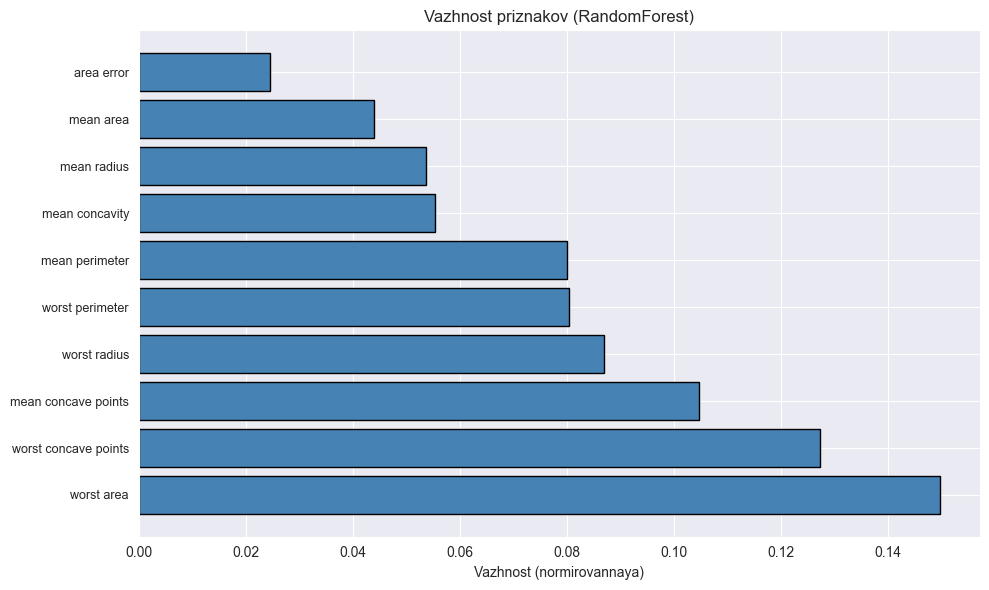

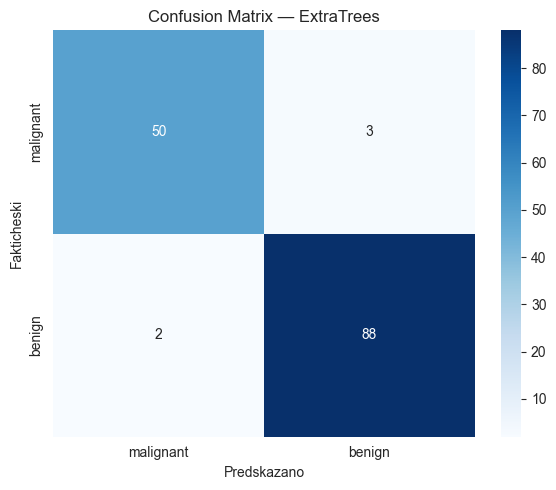

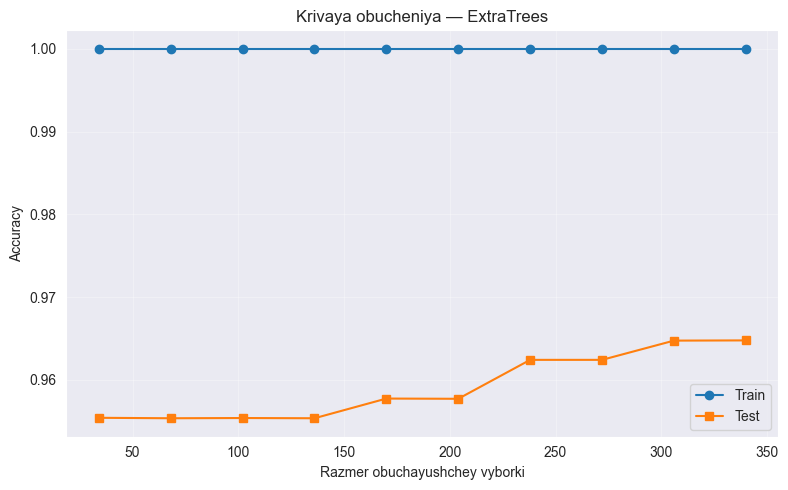

In [1]:
# !pip install scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_breast_cancer, load_iris, fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# 1️⃣ Выбор датасета
print("📊 Загрузка данных...")
data = load_breast_cancer()  # бинарная классификация, 569 образцов
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# 2️⃣ Предобработка (в этом датасете пропусков нет)
# Если есть пропуски:
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# X = imputer.fit_transform(X)

# Если есть категориальные признаки:
# le = LabelEncoder()
# X[:, col_idx] = le.fit_transform(X[:, col_idx])

# 3️⃣ Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Масштабирование (для ансамблей не обязательно, но полезно для сравнения с линейными моделями)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Обучение ансамблевых моделей
print("\n🔧 Обучение ансамблевых моделей...")
models = {}
results = {}

# 🎒 Бэггинг #1: Random Forest
print("  • RandomForest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
t0 = time.time()
rf.fit(X_train, y_train)
t_rf = time.time() - t0
y_pred_rf = rf.predict(X_test)
models['RandomForest'] = rf
results['RandomForest'] = {'time': t_rf, 'y_pred': y_pred_rf}

# 🎒 Бэггинг #2: ExtraTrees
print("  • ExtraTrees...")
et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
t0 = time.time()
et.fit(X_train, y_train)
t_et = time.time() - t0
y_pred_et = et.predict(X_test)
models['ExtraTrees'] = et
results['ExtraTrees'] = {'time': t_et, 'y_pred': y_pred_et}

# ⚡ AdaBoost
print("  • AdaBoost...")
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
t0 = time.time()
ada.fit(X_train_scaled, y_train)  # AdaBoost чувствителен к масштабу
t_ada = time.time() - t0
y_pred_ada = ada.predict(X_test_scaled)
models['AdaBoost'] = ada
results['AdaBoost'] = {'time': t_ada, 'y_pred': y_pred_ada}

# 🚀 Gradient Boosting
print("  • GradientBoosting...")
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
t0 = time.time()
gb.fit(X_train_scaled, y_train)
t_gb = time.time() - t0
y_pred_gb = gb.predict(X_test_scaled)
models['GradientBoosting'] = gb
results['GradientBoosting'] = {'time': t_gb, 'y_pred': y_pred_gb}

# 5️⃣ Оценка качества
print("\n📈 СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ:")
print(f"{'Модель':<20} | {'Accuracy':>10} | {'F1-Score':>10} | {'Время (сек)':>12}")
print("-" * 62)
for name, res in results.items():
    acc = accuracy_score(y_test, res['y_pred'])
    f1 = f1_score(y_test, res['y_pred'])
    t = res['time']
    print(f"{name:<20} | {acc:>10.4f} | {f1:>10.4f} | {t:>12.2f}")

# 6️⃣ Важность признаков (на примере RandomForest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Vazhnost priznakov (RandomForest)")
plt.barh(range(len(indices)), importances[indices][::-1], color='steelblue', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1], fontsize=9)
plt.xlabel("Vazhnost (normirovannaya)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7️⃣ Матрица ошибок для лучшей модели
best_model = max(results.keys(), key=lambda k: accuracy_score(y_test, results[k]['y_pred']))
best_pred = results[best_model]['y_pred']

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predskazano")
plt.ylabel("Fakticheski")
plt.title(f"Confusion Matrix — {best_model}")
plt.tight_layout()
plt.show()

# 8️⃣ Бонус: кривая обучения для лучшего ансамбля
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    models[best_model], X_train if 'Forest' in best_model or 'Tree' in best_model else X_train_scaled, y_train,
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train', marker='o')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test', marker='s')
plt.xlabel('Razmer obuchayushchey vyborki')
plt.ylabel('Accuracy')
plt.title(f'Krivaya obucheniya — {best_model}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()